#  HORIZON FG LOAN DEFAULT PROJECT

## PROJECT OVERVIEW
Horizon Financial Group has issued over 600 personal loans across 2024 and 2025. The company has noticed that roughly 1 in 4 loans are defaulting, which is well above their target of 12%. The VP of Risk has asked your team to analyze the existing loan book and borrower data to answer key questions about what is driving defaults. Your analysis will directly inform changes to their credit scoring model and loan approval thresholds. You have been provided two datasets: one containing borrower profiles (demographics, income, credit score, employment) and one containing loan application details (amount, term, interest rate, repayment status).

## IMPORT LIBRARIES

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
os.makedirs("images", exist_ok=True)
# warnings ignore
import warnings
warnings.filterwarnings('ignore')

# view full display
pd.set_option('display.max_columns',None)

## lOADING DATASETS

In [8]:
df1 = pd.read_csv('borrower_profiles.csv')
df2 = pd.read_csv('loan_applications.csv')

df1.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [9]:
df2.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


## combine datasets

In [10]:
data_df = pd.merge(df1, df2, on = "borrower_id", how = "left")

#data_df = data_df.with_columns (pl.col("application_date").str.to_datetime())

#data_df = data_df.drop (["loan_id", "borrower_id"])

data_df.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt,loan_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892,LN-00001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892,LN-00002,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869,LN-00003,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806,LN-00004,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928,LN-00005,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [11]:
#data types
data_df.dtypes

,0
borrower_id,object
age,int64
state,object
education_level,object
employment_status,object
years_employed,int64
annual_income,int64
credit_score,int64
home_ownership,object
dependents,int64


In [12]:
#basic statistics
data_df.describe()

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,45.133111,10.920133,65056.509151,705.745424,1.339434,1624.184692,22148.252912,36.539101,10.641331,948.337654,49.680699,27.036606,0.242928
std,13.679264,9.353267,29217.561391,98.216462,1.246833,1124.974225,13215.261422,16.898192,2.251153,864.959543,24.113652,47.802845,0.429209
min,22.000000,0.000000,12549.000000,528.000000,0.000000,124.000000,2000.000000,12.000000,5.860000,44.140000,7.600000,0.000000,0.000000
25%,33.000000,3.000000,43022.000000,617.000000,0.000000,791.000000,10900.000000,24.000000,8.940000,359.860000,32.200000,0.000000,0.000000
50%,45.000000,8.000000,59967.000000,707.000000,1.000000,1316.000000,20400.000000,36.000000,10.540000,684.870000,48.100000,0.000000,0.000000
75%,57.000000,17.000000,81309.000000,796.000000,2.000000,2207.000000,32700.000000,48.000000,12.330000,1165.200000,62.400000,30.000000,0.000000
max,68.000000,35.000000,157047.000000,850.000000,4.000000,6130.000000,49800.000000,60.000000,15.860000,4262.690000,177.400000,180.000000,1.000000


## Data Manipulation

In [13]:
#create credit score buckets
for col in data_df.columns:
  if data_df[col].dtype == 'O':
    print(col,":",data_df[col].nunique())

borrower_id : 500
state : 30
education_level : 5
employment_status : 5
home_ownership : 3
loan_id : 601
application_date : 369
loan_purpose : 10
loan_status : 4


In [14]:
req_cat_cols = ['loan_purpose','loan_status','education_level','employment_status','home_ownership']

for col in req_cat_cols:
    data_df[col] = data_df[col].astype('category')

In [15]:
# Bins for creditscore
data_df['credit_score'].describe()

,credit_score
count,601.000000
mean,705.745424
std,98.216462
min,528.000000
25%,617.000000
50%,707.000000
75%,796.000000
max,850.000000


In [16]:
# Credit score range : 520–599, 600–649, 650–699, 700–749, 750+
labels = ['520–599', '600–649', '650–699', '700–749', '750+']
bins = [520,600,650,700,750,float('inf')]
data_df['credit_score_bins'] = pd.cut(x=data_df['credit_score'],bins = bins,labels = labels,include_lowest=True,right=False)

In [17]:
# Bins for DTI range
data_df['dti_ratio'].describe()

,dti_ratio
count,601.000000
mean,49.680699
std,24.113652
min,7.600000
25%,32.200000
50%,48.100000
75%,62.400000
max,177.400000


In [18]:
#COMBINED DATASET
#data_df.to_csv("foo.csv")

In [19]:
# DTI Ratio : 5-24,25-49,50-74,75-99,100-124,125-149,150-174,175+
bins = [5,25,50,75,100,125,150,175,float('inf')]
labels = ['5–24','25–49','50–74','75–99','100–124','125–149','150–174','175+']
data_df['dti_bins'] = pd.cut(x=data_df['dti_ratio'],bins=bins,labels=labels,include_lowest=True,right=False)

## BASIC VISUALISATION

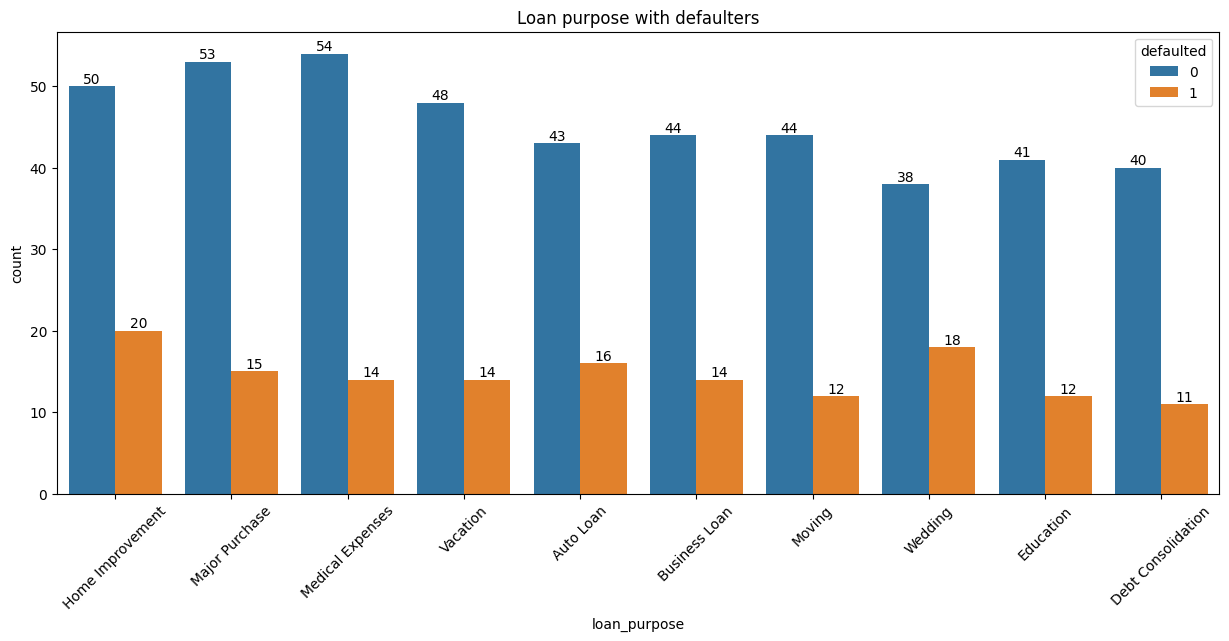

In [24]:
plt.figure(figsize=(15,6))
order = data_df['loan_purpose'].value_counts().index
ax = sns.countplot(data=data_df,x='loan_purpose',hue='defaulted',order=order)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Loan purpose with defaulters')
plt.xticks(rotation= 45)
plt.savefig("images/loan_purpose.png", bbox_inches='tight')
plt.show()

### Default Rate by Credit Score Range

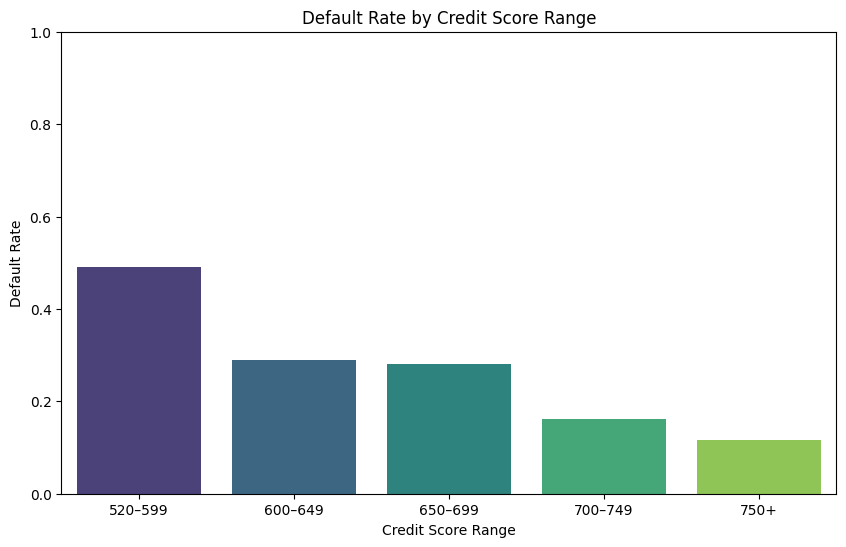

In [25]:
plt.figure(figsize=(10, 6))
default_rate_credit_score = data_df.groupby('credit_score_bins')['defaulted'].mean().reset_index()
sns.barplot(x='credit_score_bins', y='defaulted', data=default_rate_credit_score, palette='viridis')
plt.title('Default Rate by Credit Score Range')
plt.xlabel('Credit Score Range')
plt.ylabel('Default Rate')
plt.ylim(0, 1) # Ensure y-axis is between 0 and 1 for default rate
plt.savefig("images/default_rate_credit_score.png", bbox_inches='tight')
plt.show()

### DTI Ratio vs. Default Status

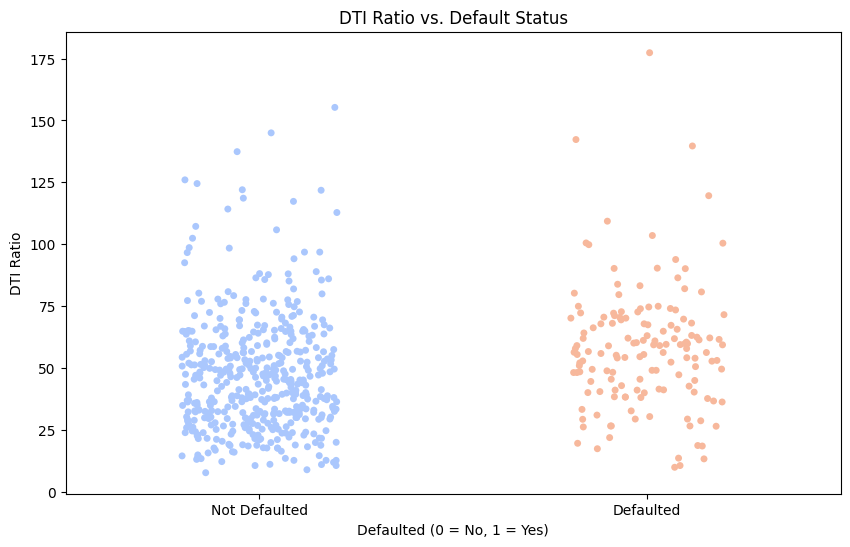

In [26]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='defaulted', y='dti_ratio', data=data_df, jitter=0.2, hue='defaulted', palette='coolwarm', legend=False)
plt.title('DTI Ratio vs. Default Status')
plt.xlabel('Defaulted (0 = No, 1 = Yes)')
plt.ylabel('DTI Ratio')
plt.xticks([0, 1], ['Not Defaulted', 'Defaulted'])
plt.savefig("images/dti_vs_default.png", bbox_inches='tight')
plt.show()

### Loan Purpose Distribution

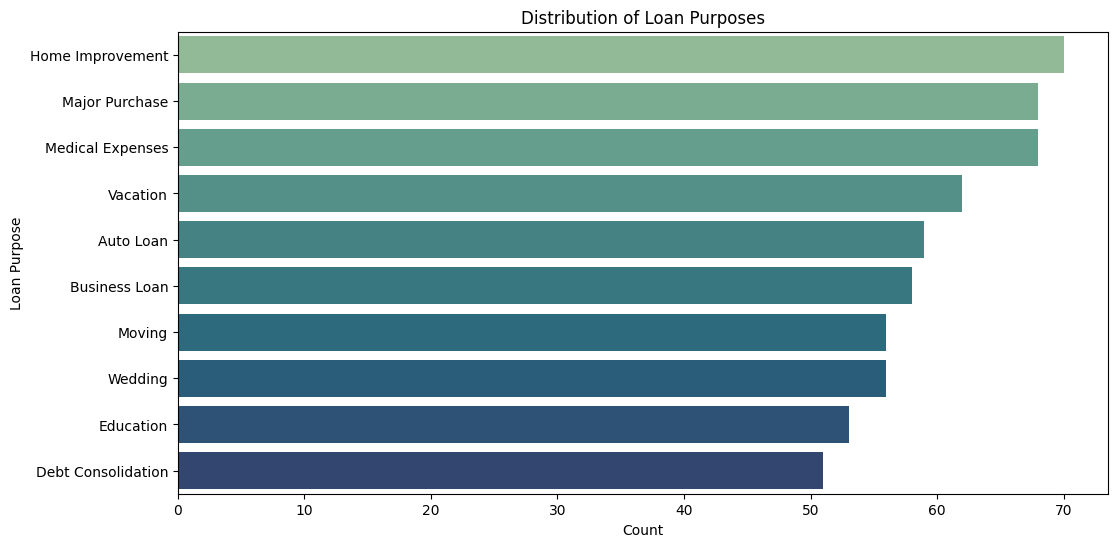

In [28]:
plt.figure(figsize=(12, 6))
sns.countplot(y='loan_purpose', data=data_df, order=data_df['loan_purpose'].value_counts().index, palette='crest')
plt.title('Distribution of Loan Purposes')
plt.xlabel('Count')
plt.ylabel('Loan Purpose')
plt.savefig("images/loan_purpose_distribution.png", bbox_inches='tight')
plt.show()

### Default Rate by DTI Ratio

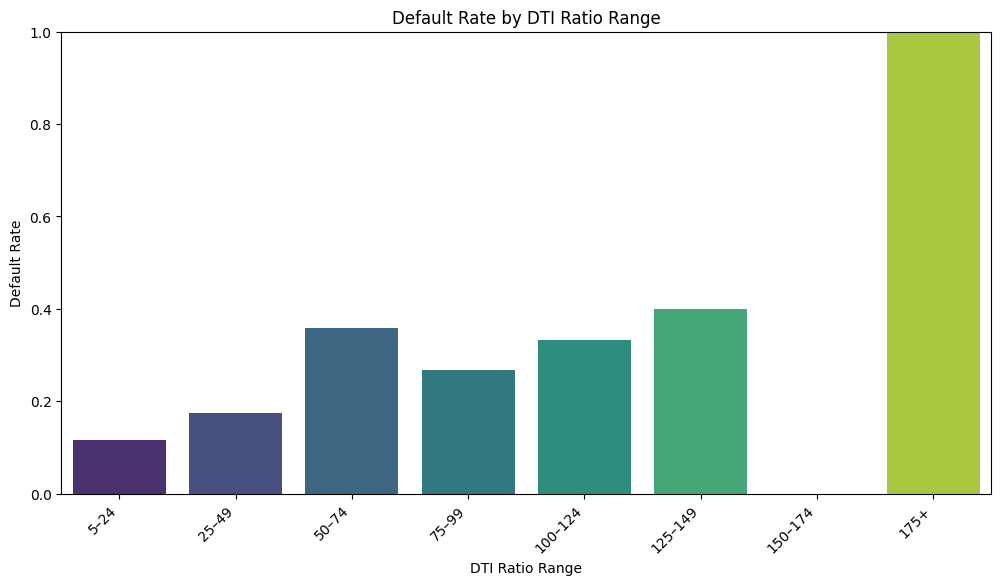

Default Rate by DTI Ratio:
   dti_bins  defaulted
0     5–24   0.115385
1    25–49   0.174603
2    50–74   0.357843
3    75–99   0.266667
4  100–124   0.333333
5  125–149   0.400000
6  150–174   0.000000
7     175+   1.000000


In [29]:
plt.figure(figsize=(12, 6))
default_rate_dti = data_df.groupby('dti_bins')['defaulted'].mean().reset_index()
sns.barplot(x='dti_bins', y='defaulted', data=default_rate_dti, palette='viridis')
plt.title('Default Rate by DTI Ratio Range')
plt.xlabel('DTI Ratio Range')
plt.ylabel('Default Rate')
plt.ylim(0, 1) # Ensure y-axis is between 0 and 1 for default rate
plt.xticks(rotation=45, ha='right')
plt.savefig("images/default_rate_dti.png", bbox_inches='tight')
plt.show()

print("Default Rate by DTI Ratio:\n", default_rate_dti)

Given the significant increase in default rates for DTI ratios above 50%, I would recommend a DTI threshold of 50% as a cut-off for loan approval. Loans granted to borrowers with a DTI ratio below 50% appear to have a substantially lower default risk (e.g., 11.5% for 5-24 and 17.5% for 25-49), whereas exceeding this threshold doubles the default rate to over 35%. While individual cases might vary, this threshold provides a reasonable balance to mitigate overall default risk for Horizon Financial Group. Further analysis with larger datasets for each DTI bin, especially the '150–174' bin, would provide more robust insights.

### Default Rate by Employment Status

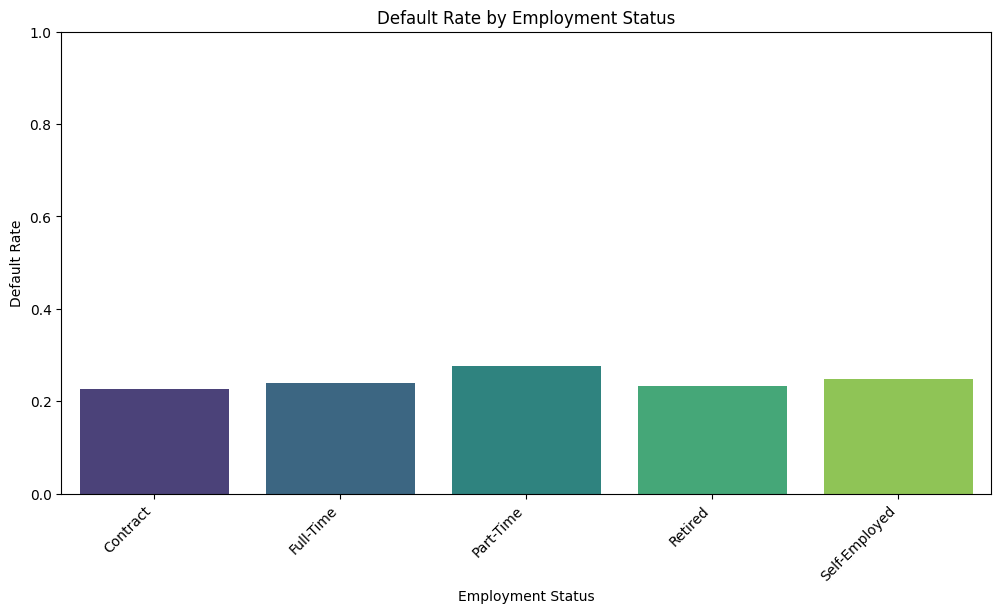

Default Rate by Employment Status:
   employment_status  defaulted
0          Contract   0.227273
1         Full-Time   0.239344
2         Part-Time   0.276923
3           Retired   0.233333
4     Self-Employed   0.247619


In [30]:
plt.figure(figsize=(12, 6))
default_rate_employment = data_df.groupby('employment_status')['defaulted'].mean().reset_index()
sns.barplot(x='employment_status', y='defaulted', data=default_rate_employment, palette='viridis')
plt.title('Default Rate by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Default Rate')
plt.ylim(0, 1) # Ensure y-axis is between 0 and 1 for default rate
plt.xticks(rotation=45, ha='right')
plt.savefig("images/default_rate_employment_status.png", bbox_inches='tight')
plt.show()

print("Default Rate by Employment Status:\n", default_rate_employment)

### Default Rate by Years Employed (with focus on < 2 years)

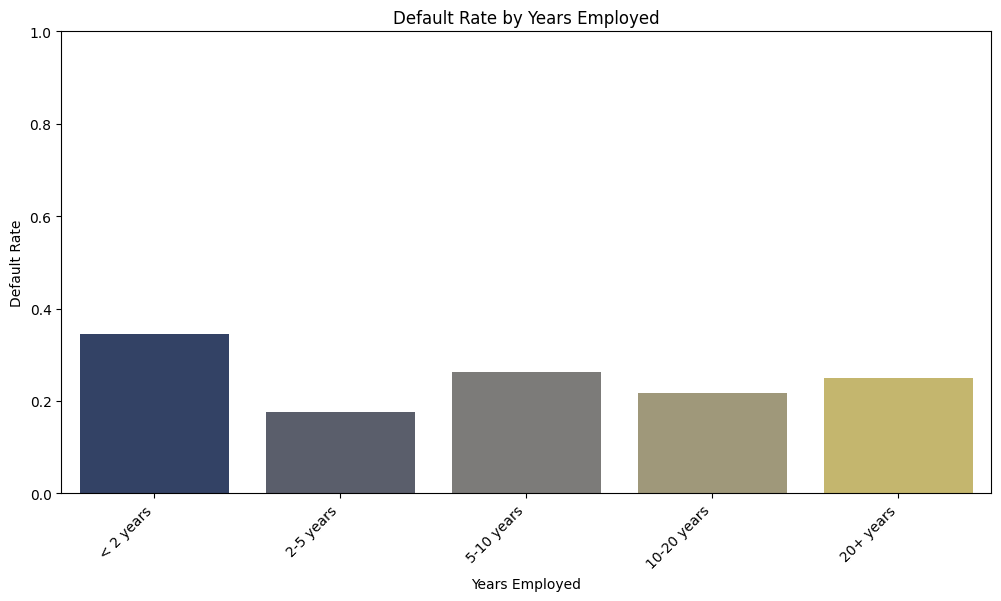

Default Rate by Years Employed:
   years_employed_bins  defaulted
0           < 2 years   0.345238
1           2-5 years   0.175439
2          5-10 years   0.261905
3         10-20 years   0.218182
4           20+ years   0.250000

Default rate for borrowers with less than 2 years of employment: 34.52%


In [31]:
# Create bins for years_employed
bins_years_employed = [-float('inf'), 2, 5, 10, 20, float('inf')]
labels_years_employed = ['< 2 years', '2-5 years', '5-10 years', '10-20 years', '20+ years']
data_df['years_employed_bins'] = pd.cut(x=data_df['years_employed'], bins=bins_years_employed, labels=labels_years_employed, include_lowest=True, right=False)

plt.figure(figsize=(12, 6))
default_rate_years_employed = data_df.groupby('years_employed_bins')['defaulted'].mean().reset_index()
sns.barplot(x='years_employed_bins', y='defaulted', data=default_rate_years_employed, palette='cividis')
plt.title('Default Rate by Years Employed')
plt.xlabel('Years Employed')
plt.ylabel('Default Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.savefig("images/default_rate_years_employed.png", bbox_inches='tight')
plt.show()

print("Default Rate by Years Employed:\n", default_rate_years_employed)

# Specifically check for < 2 years
default_less_than_2_years = data_df[data_df['years_employed'] < 2]['defaulted'].mean()
print(f"\nDefault rate for borrowers with less than 2 years of employment: {default_less_than_2_years:.2%}")

Employment Status: Does not appear to be a major differentiating factor for default risk in this dataset.
Years Employed: Yes, borrowers with less than 2 years of employment are significantly more likely to default (34.52%) compared to any other group, especially those with 2-5 years of employment (17.5%). This suggests that job stability, as indicated by longer employment duration (beyond the initial two years), could be a valuable factor in assessing loan applications. Horizon Financial Group might consider this a key indicator for higher risk.

## Final Recommendations for Underwriting

Based on the analysis, here are the top 3 risk factors and recommended thresholds for the credit scoring model:

### 1. Credit Score (Highest Impact)
*   **Finding:** Borrowers with scores below 600 have a nearly 50% default rate.
*   **Recommendation:** Set a **minimum credit score of 650**.
*   **Impact:** This targets the cohorts where default rates drop significantly (from ~29% to ~16%).

### 2. Debt-to-Income (DTI) Ratio
*   **Finding:** Default rates double (from ~17% to ~36%) once the DTI ratio exceeds 50%.
*   **Recommendation:** Implement a **maximum DTI threshold of 50%**.
*   **Impact:** High-DTI borrowers are over-leveraged and represent a volatility risk to the portfolio.

### 3. Employment Stability
*   **Finding:** Borrowers with less than 2 years at their current job are significantly more likely to default (34.5% vs ~17.5% for those with 2-5 years).
*   **Recommendation:** Require a **minimum of 2 years of continuous employment** for standard approval.
*   **Impact:** This filter targets job instability, which is a strong secondary predictor of repayment failure.